# ESN Porto Students Dataset Analysis

**Analysis Period:** Academic Years 2020-2021 through 2025-2026

## 1. Setup & Data Loading

In [153]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.stats import chi2_contingency, normaltest, mannwhitneyu
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from collections import Counter
import re

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully")

Libraries imported successfully


In [154]:
data_dir = Path('data')
files = sorted(data_dir.glob('students_*_privatized.json'))

all_students = []
metadata_by_year = {}

for file in files:
    year = file.stem.split('_')[1]  # Extract academic year
    
    with open(file, 'r') as f:
        data = json.load(f)
    
    metadata_by_year[year] = {
        'newStudents': data.get('newStudents', 0),
        'validStudents': data.get('validStudents', 0),
        'sales': data.get('sales', 0),
        'pendingCards': data.get('pendingCards', 0),
        'pendingPurchases': data.get('pendingPurchases', 0)
    }
    
    # Add academic year to each student record
    for student in data.get('students', []):
        student['academic_year'] = year
        all_students.append(student)

df = pd.DataFrame(all_students)

df_metadata = pd.DataFrame(metadata_by_year).T
df_metadata.index.name = 'academic_year'

print(f"Loaded {len(files)} files")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded 6 files
Total students: 14,555
Academic years: ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']


## 2. Data Preprocessing & Feature Engineering

In [155]:
# Convert timestamps to datetime
df['birthdate_dt'] = pd.to_datetime(df['birthdate'], unit='ms', errors='coerce')
df['registerDate_dt'] = pd.to_datetime(df['registerDate'], unit='ms', errors='coerce')

# Calculate age at registration
df['age_at_registration'] = (df['registerDate_dt'] - df['birthdate_dt']).dt.days / 365.25

# Extract temporal features
df['register_year'] = df['registerDate_dt'].dt.year
df['register_month'] = df['registerDate_dt'].dt.month
df['register_quarter'] = df['registerDate_dt'].dt.quarter
df['register_weekday'] = df['registerDate_dt'].dt.dayofweek
df['register_day'] = df['registerDate_dt'].dt.day

# Create month name for better visualization
df['register_month_name'] = df['registerDate_dt'].dt.strftime('%B')

# Extract birth year and current age
df['birth_year'] = df['birthdate_dt'].dt.year
current_date = datetime.now()
df['current_age'] = (current_date - df['birthdate_dt']).dt.days / 365.25

df['program_category'] = df['program'].apply(lambda x: 
    'Erasmus' if 'Erasmus' in str(x) else
    'Volunteer' if 'Volunteer' in str(x) or 'Buddy' in str(x) or 'Alumni' in str(x) else
    'Exchange' if 'exchange' in str(x).lower() else
    'Other'
)

# Simplify university names
df['university_short'] = df['university'].apply(lambda x: 
    re.search(r'\((\w+)\)', str(x)).group(1) if re.search(r'\((\w+)\)', str(x)) else str(x)
)

# Flag Portuguese vs International students
df['is_international'] = (df['country'] != 'Portugal').astype(int)

# Academic semester (approximate)
df['academic_semester'] = df['register_month'].apply(lambda x: 
    'Fall' if x in [9, 10, 11, 12, 1] else 'Spring'
)

print("Feature engineering completed")
print(f"\nDataframe shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Feature engineering completed

Dataframe shape: (14555, 26)
Columns: ['gender', 'birthdate', 'address', 'country', 'organization', 'university', 'registerDate', '__v', 'academic_year', 'program', 'programDuration', 'birthdate_dt', 'registerDate_dt', 'age_at_registration', 'register_year', 'register_month', 'register_quarter', 'register_weekday', 'register_day', 'register_month_name', 'birth_year', 'current_age', 'program_category', 'university_short', 'is_international', 'academic_semester']


## 3. Data Quality Assessment

In [156]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percent': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("\n")
print("MISSING VALUES ANALYSIS")
print("\n")
print(missing_summary[missing_summary['Missing_Count'] > 0])
print(f"\nColumns with no missing values: {len(missing_summary[missing_summary['Missing_Count'] == 0])}")



MISSING VALUES ANALYSIS


                 Column  Missing_Count  Missing_Percent
9               program              4             0.03
10      programDuration              4             0.03
21          current_age              1             0.01
13  age_at_registration              1             0.01
11         birthdate_dt              1             0.01
20           birth_year              1             0.01

Columns with no missing values: 20


In [157]:
# Data quality checks
quality_checks = {
    'Total Records': len(df),
    'Complete Records': len(df.dropna()),
    'Duplicate Rows': df.duplicated().sum(),
    'Invalid Ages (< 15 or > 100)': ((df['age_at_registration'] < 15) | (df['age_at_registration'] > 100)).sum(),
    'Future Registration Dates': (df['registerDate_dt'] > current_date).sum(),
    'Future Birth Dates': (df['birthdate_dt'] > current_date).sum(),
    'Registration Before Birth': (df['registerDate_dt'] < df['birthdate_dt']).sum(),
    'Missing Gender': df['gender'].isnull().sum(),
    'Missing Country': df['country'].isnull().sum(),
}

print("\n")
print("DATA QUALITY CHECKS")
print("\n")
for check, value in quality_checks.items():
    status = "✓" if value == 0 else "⚠"
    print(f"{status} {check}: {value:,}")



DATA QUALITY CHECKS


⚠ Total Records: 14,555
⚠ Complete Records: 14,550
✓ Duplicate Rows: 0
⚠ Invalid Ages (< 15 or > 100): 28
✓ Future Registration Dates: 0
⚠ Future Birth Dates: 2
⚠ Registration Before Birth: 16
✓ Missing Gender: 0
✓ Missing Country: 0


## 4. Univariate Analysis

### 4.1 Demographic Distributions

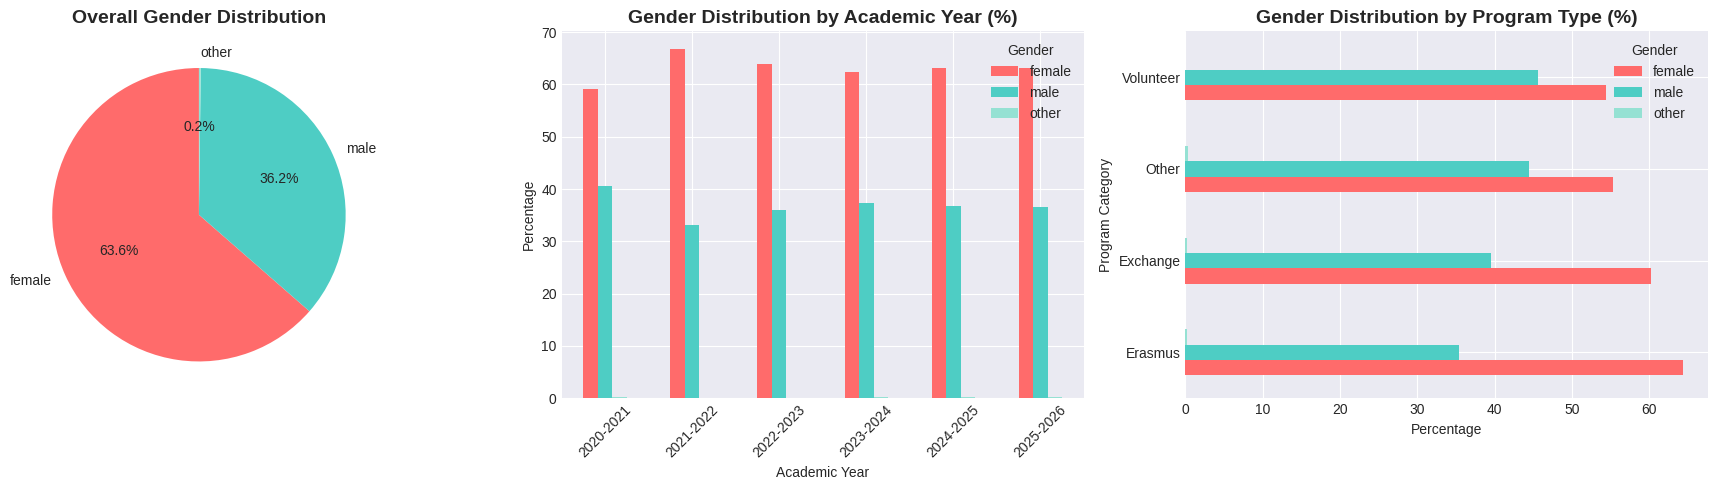

Gender ratio (F:M): 1.75:1


In [158]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall gender distribution
gender_counts = df['gender'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Overall Gender Distribution', fontsize=14, fontweight='bold')

# Gender distribution by academic year
gender_by_year = pd.crosstab(df['academic_year'], df['gender'], normalize='index') * 100
gender_by_year.plot(kind='bar', ax=axes[1], color=colors[:len(gender_by_year.columns)])
axes[1].set_title('Gender Distribution by Academic Year (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)

# Gender distribution by program category
gender_by_program = pd.crosstab(df['program_category'], df['gender'], normalize='index') * 100
gender_by_program.plot(kind='barh', ax=axes[2], color=colors[:len(gender_by_program.columns)])
axes[2].set_title('Gender Distribution by Program Type (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Percentage')
axes[2].set_ylabel('Program Category')
axes[2].legend(title='Gender')

plt.tight_layout()
plt.show()

print(f"Gender ratio (F:M): {gender_counts['female']/gender_counts['male']:.2f}:1")

The gender split shows a clear female majority (~64%) that holds remarkably steady across all years and program types. This 1.75:1 ratio is expected as women are also the majority of european university students.

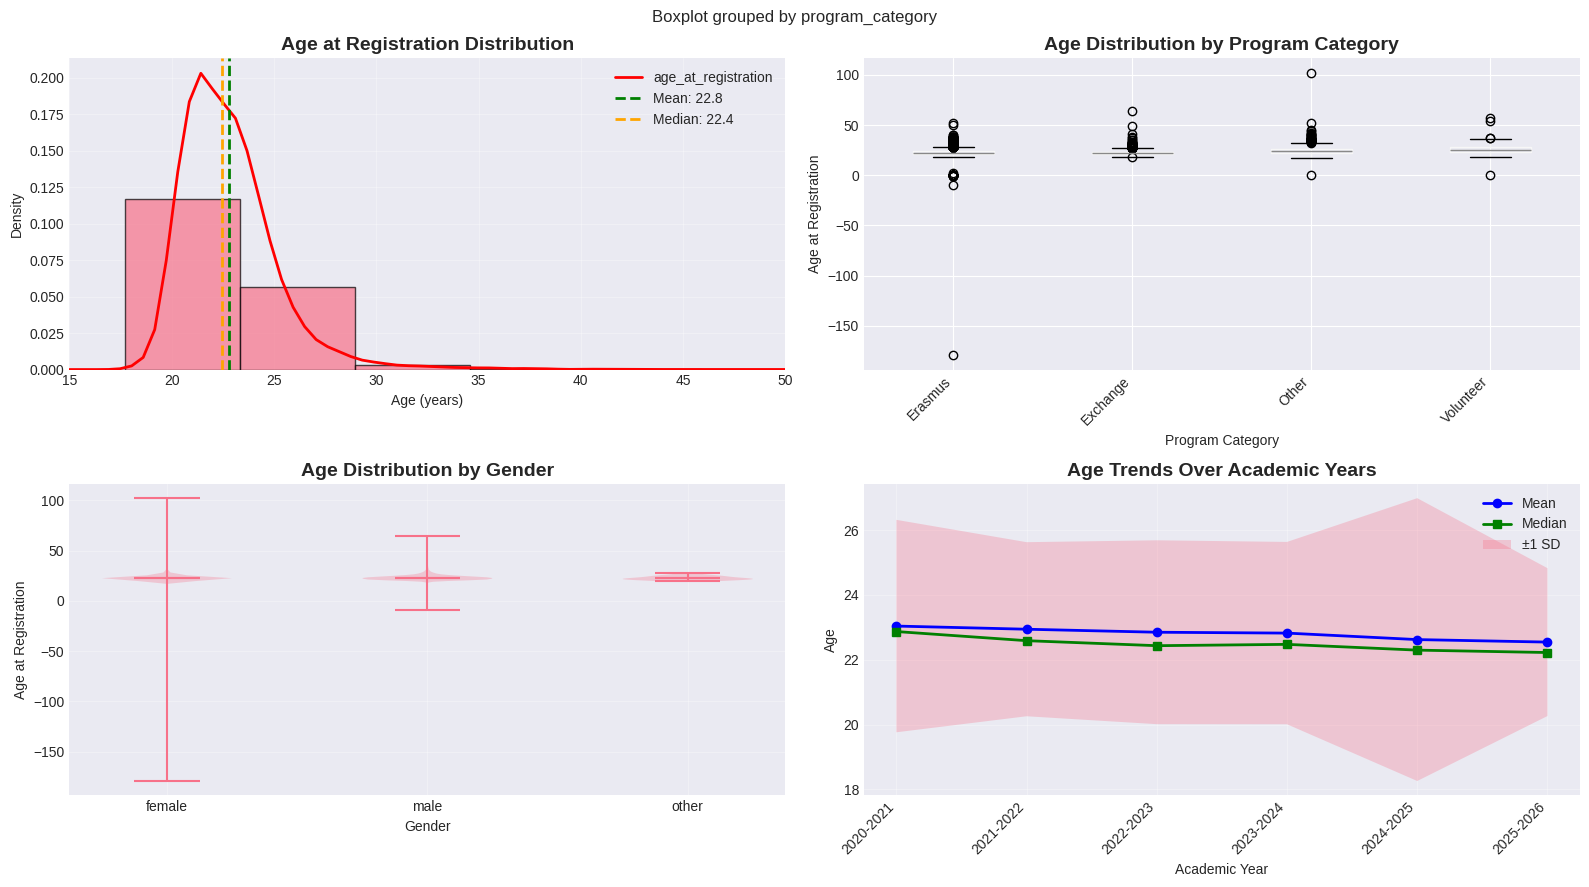


Age Statistics:
count   14554.00
mean       22.78
std         3.21
min      -179.35
25%        21.18
50%        22.44
75%        23.90
max       102.17
Name: age_at_registration, dtype: float64


In [159]:
# Age distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Age at registration - histogram
axes[0, 0].hist(df['age_at_registration'].dropna(), bins=50, edgecolor='black', alpha=0.7, density=True)
df['age_at_registration'].dropna().plot(kind='kde', ax=axes[0, 0], linewidth=2, color='red')
axes[0, 0].axvline(df['age_at_registration'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {df['age_at_registration'].mean():.1f}")
axes[0, 0].axvline(df['age_at_registration'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['age_at_registration'].median():.1f}")
axes[0, 0].set_title('Age at Registration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(15, 50)

# Box plot - Age by program category
df.boxplot(column='age_at_registration', by='program_category', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Program Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Program Category')
axes[0, 1].set_ylabel('Age at Registration')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# Violin plot - Age by gender
parts = axes[1, 0].violinplot(
    [df[df['gender'] == g]['age_at_registration'].dropna() for g in df['gender'].unique()],
    positions=range(len(df['gender'].unique())),
    showmeans=True,
    showmedians=True
)
axes[1, 0].set_xticks(range(len(df['gender'].unique())))
axes[1, 0].set_xticklabels(df['gender'].unique())
axes[1, 0].set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Age at Registration')
axes[1, 0].grid(alpha=0.3)

# Age distribution over time
age_by_year = df.groupby('academic_year')['age_at_registration'].agg(['mean', 'median', 'std'])
x = range(len(age_by_year))
axes[1, 1].plot(x, age_by_year['mean'], marker='o', linewidth=2, label='Mean', color='blue')
axes[1, 1].plot(x, age_by_year['median'], marker='s', linewidth=2, label='Median', color='green')
axes[1, 1].fill_between(x, 
                         age_by_year['mean'] - age_by_year['std'],
                         age_by_year['mean'] + age_by_year['std'],
                         alpha=0.3, label='±1 SD')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(age_by_year.index, rotation=45, ha='right')
axes[1, 1].set_title('Age Trends Over Academic Years', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Academic Year')
axes[1, 1].set_ylabel('Age')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAge Statistics:")
print(df['age_at_registration'].describe())

Students cluster tightly around 22-23 years old with minimal variation across genders and program, exactly what we'd expect for undergraduate exchange students. The age stability over time suggests consistent partnerships with institutions at similar academic levels. Those outliers flagged in the data quality check need to be cleaned up eventhough they're a tiny fraction of the dataset (possibly resulted from human error).

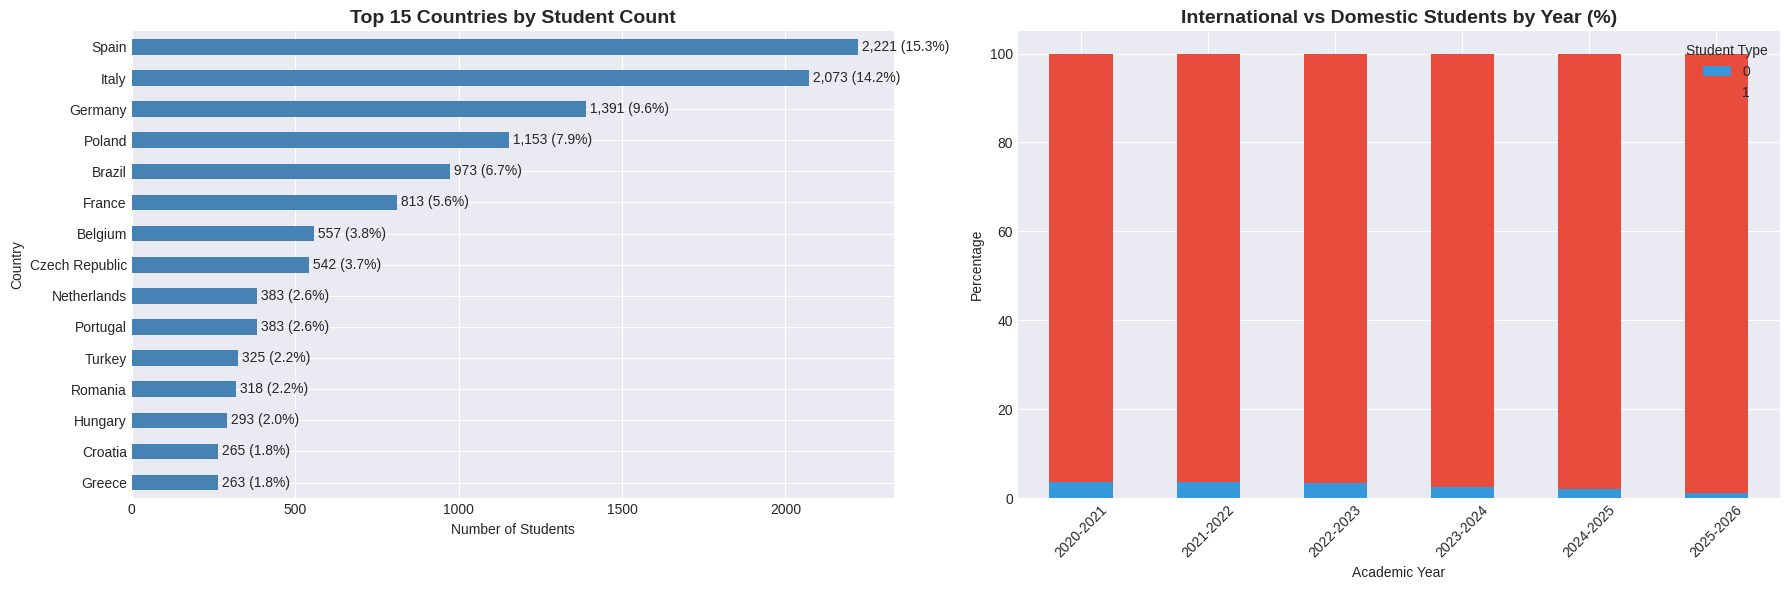


Total unique countries: 145
International students: 14,172 (97.4%)


In [160]:
# Country analysis
top_n = 15
country_counts = df['country'].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top countries bar chart
country_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Top {top_n} Countries by Student Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('Country')
axes[0].invert_yaxis()

# Add percentage labels
total = len(df)
for i, (country, count) in enumerate(country_counts.items()):
    axes[0].text(count, i, f' {count:,} ({count/total*100:.1f}%)', va='center')

# International vs Domestic over time
intl_by_year = df.groupby(['academic_year', 'is_international']).size().unstack(fill_value=0)
intl_by_year_pct = intl_by_year.div(intl_by_year.sum(axis=1), axis=0) * 100

intl_by_year_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                       color=['#3498db', '#e74c3c'],
                       label=['Domestic (Portugal)', 'International'])
axes[1].set_title('International vs Domestic Students by Year (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Student Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTotal unique countries: {df['country'].nunique()}")
print(f"International students: {df['is_international'].sum():,} ({df['is_international'].mean()*100:.1f}%)")


The 97.4% international rate is expected, the small domestic portion mostly represents ESN Porto section members. Geographic distribution follows a clear pattern: Southern European countries (Spain, Italy) dominate due to Erasmus partnerships and cultural proximity, followed by Germany and Poland. Having 145 countries represented is impressive, though the top 5 account for over half the students. Brazil's strong showing (#5) stems from historical and linguistic connections with Portugal, and resulted from the "intercâmbio" program between the two countries.

### 4.2 Academic Patterns

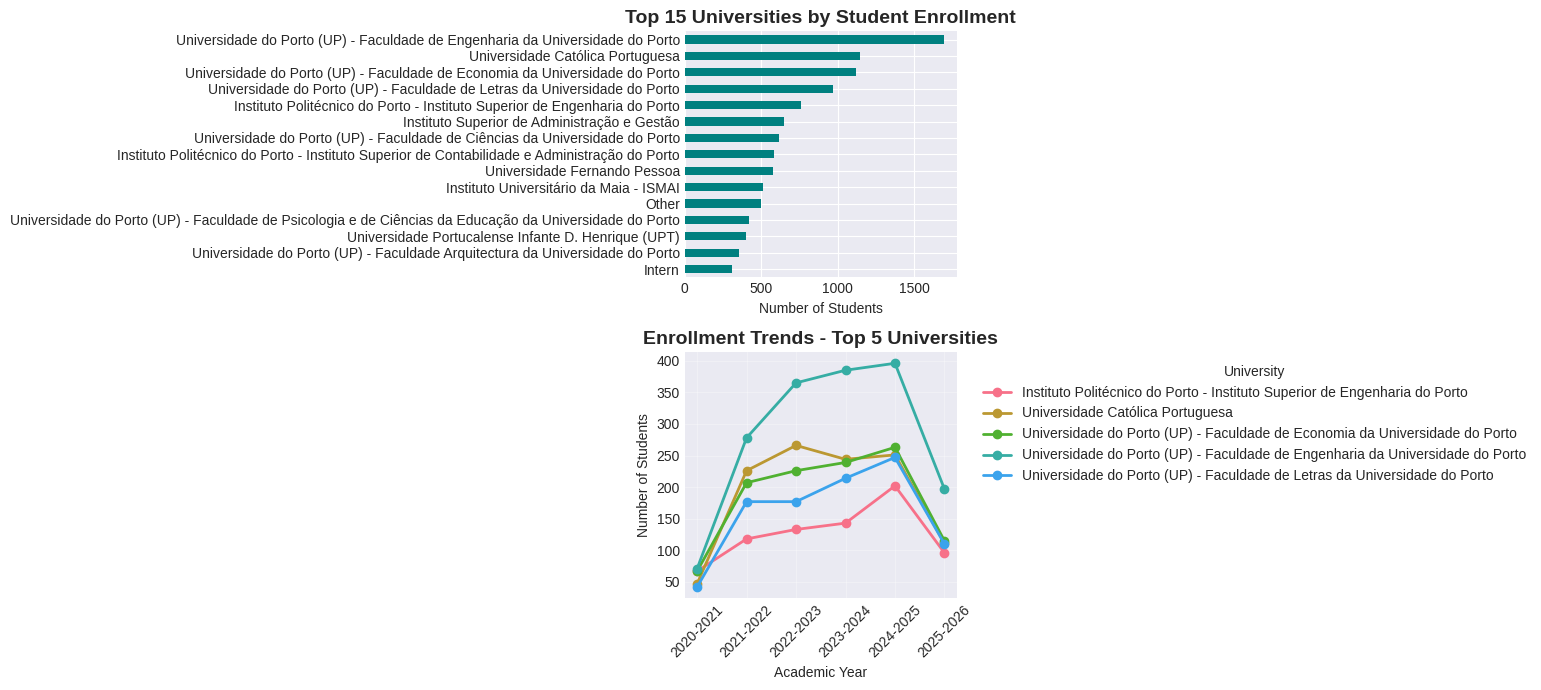

In [161]:
# University distribution
top_universities = df['university'].value_counts().head(15)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

# Top universities
top_universities.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Universities by Student Enrollment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

# University distribution over time (top 5)
top_5_unis = df['university'].value_counts().head(5).index
uni_by_year = df[df['university'].isin(top_5_unis)].groupby(['academic_year', 'university']).size().unstack(fill_value=0)

uni_by_year.plot(kind='line', ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Enrollment Trends - Top 5 Universities', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='University', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Universidade do Porto dominates, especially the Engineering faculty (FEUP). The flattening growth curves after 2023-2024 suggest these partnerships have matured, with enrollment likely capped by practical constraints like housing and course capacity rather than lack of demand.

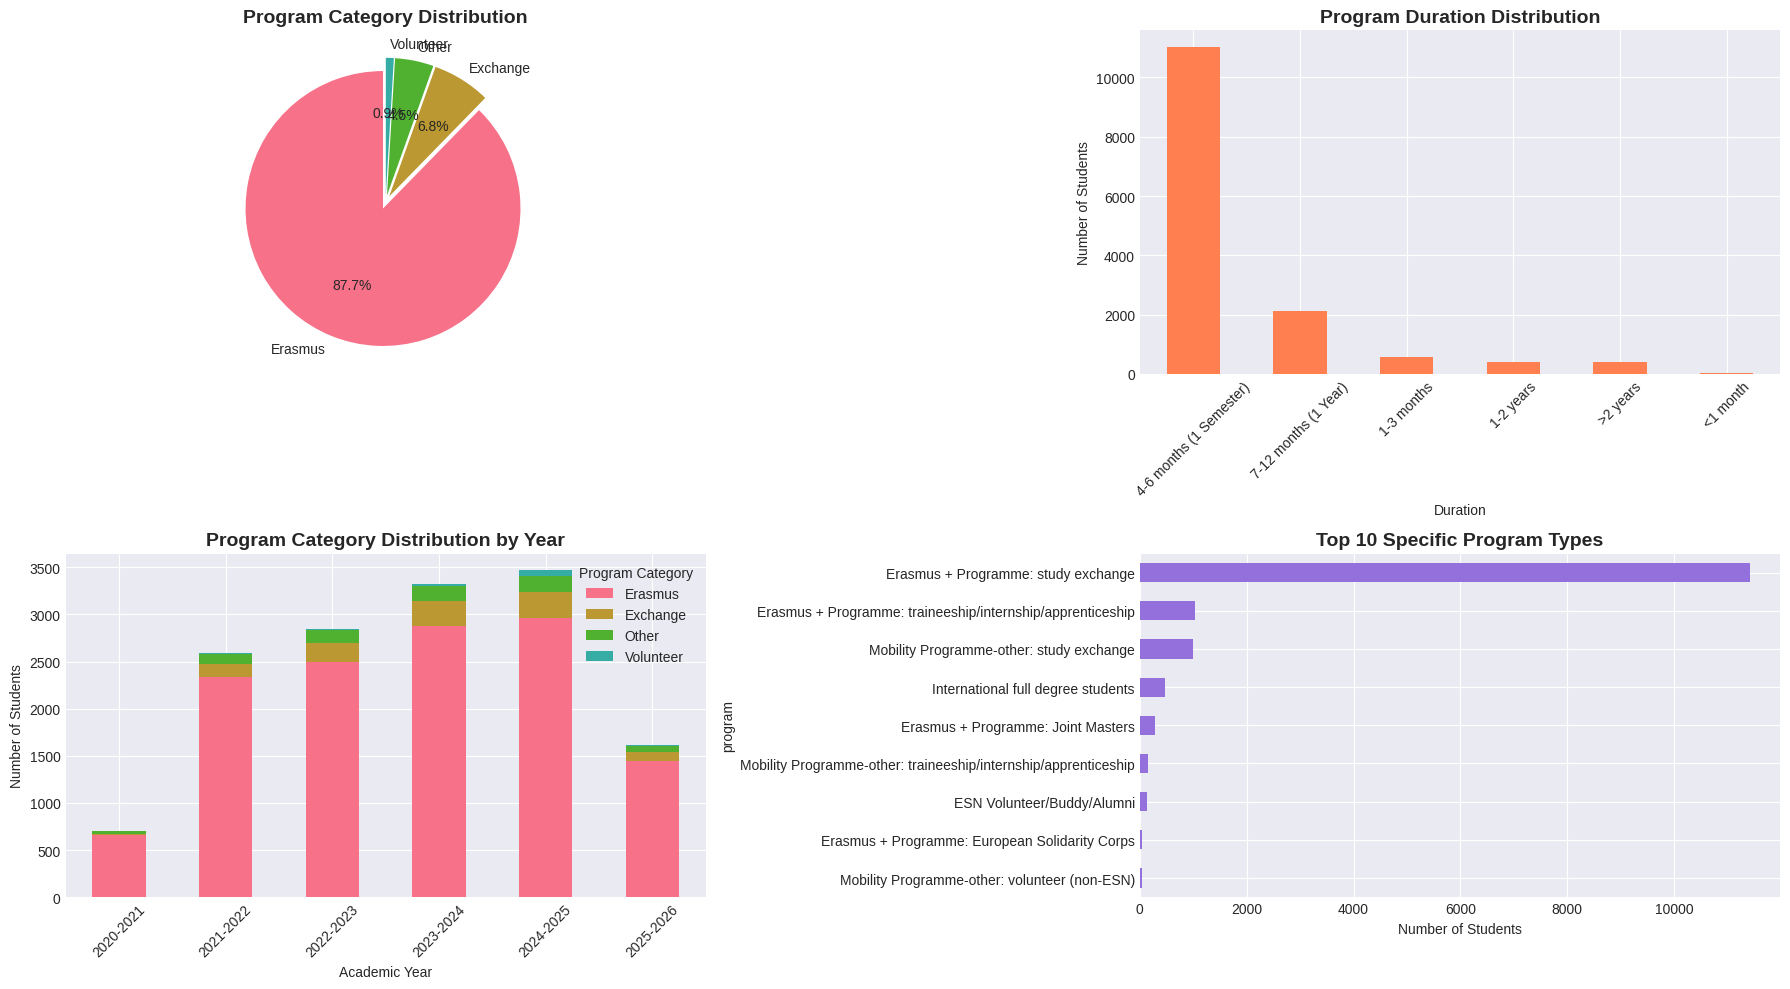

In [162]:
# Program analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Program category distribution
program_cat_counts = df['program_category'].value_counts()
axes[0, 0].pie(program_cat_counts.values, labels=program_cat_counts.index, 
               autopct='%1.1f%%', startangle=90, explode=[0.05]*len(program_cat_counts))
axes[0, 0].set_title('Program Category Distribution', fontsize=14, fontweight='bold')

# Program duration
duration_counts = df['programDuration'].value_counts()
duration_counts.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Program Duration Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Duration')
axes[0, 1].set_ylabel('Number of Students')
axes[0, 1].tick_params(axis='x', rotation=45)

# Program category by year
program_by_year = pd.crosstab(df['academic_year'], df['program_category'])
program_by_year.plot(kind='bar', stacked=True, ax=axes[1, 0])
axes[1, 0].set_title('Program Category Distribution by Year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Academic Year')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].legend(title='Program Category')
axes[1, 0].tick_params(axis='x', rotation=45)

# Detailed program types (top 10)
top_programs = df['program'].value_counts().head(10)
top_programs.plot(kind='barh', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Top 10 Specific Program Types', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Students')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

Erasmus programs dominate at nearly 90%, with semester-long stays being the norm. The program mix stays remarkably stable year-over-year

### 4.3 Temporal Analysis

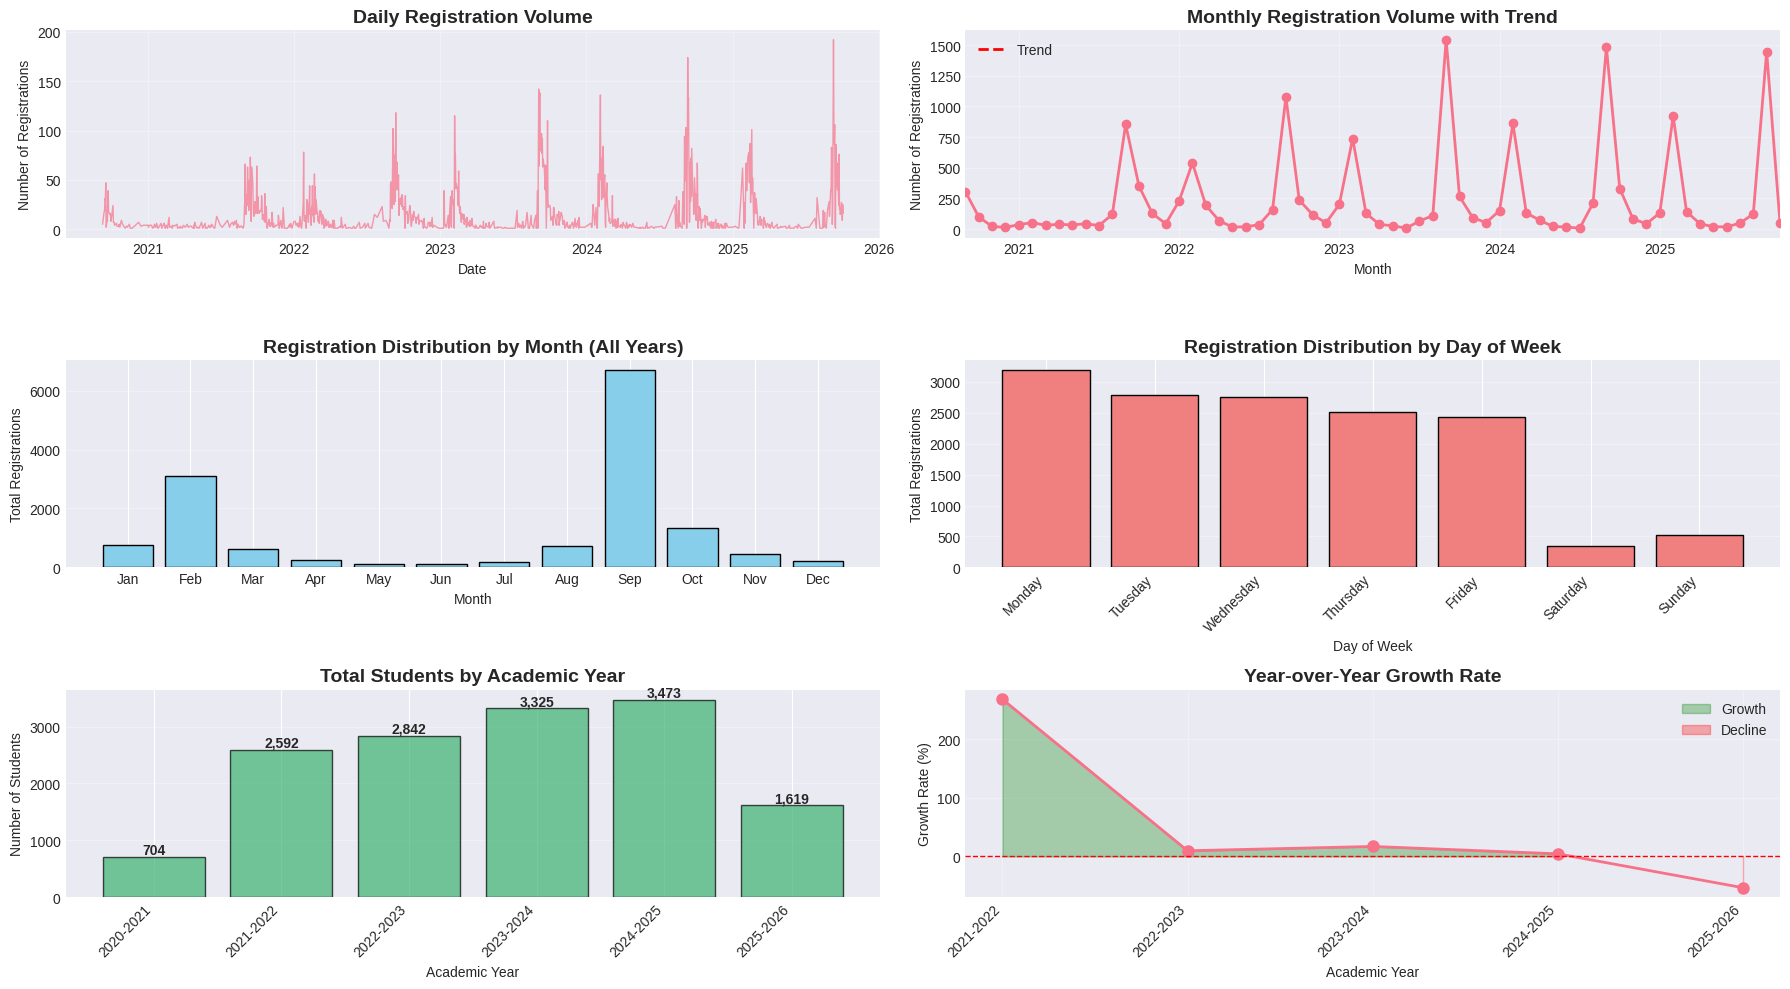


Yearly Registration Summary:
academic_year
2020-2021     704
2021-2022    2592
2022-2023    2842
2023-2024    3325
2024-2025    3473
2025-2026    1619
Name: count, dtype: int64

Year-over-Year Growth:
academic_year
2021-2022   268.18
2022-2023     9.65
2023-2024    17.00
2024-2025     4.45
2025-2026   -53.38
Name: count, dtype: float64


In [163]:
# Registration patterns over time
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# Daily registrations time series
daily_reg = df.groupby(df['registerDate_dt'].dt.date).size()
daily_reg.plot(ax=axes[0, 0], linewidth=1, alpha=0.7)
axes[0, 0].set_title('Daily Registration Volume', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Registrations')
axes[0, 0].grid(alpha=0.3)

# Monthly registrations with trend
monthly_reg = df.groupby(df['registerDate_dt'].dt.to_period('M')).size()
monthly_reg.index = monthly_reg.index.to_timestamp()
monthly_reg.plot(ax=axes[0, 1], linewidth=2, marker='o')

# Add trend line
z = np.polyfit(range(len(monthly_reg)), monthly_reg.values, 1)
p = np.poly1d(z)
axes[0, 1].plot(monthly_reg.index, p(range(len(monthly_reg))), "r--", linewidth=2, label='Trend')

axes[0, 1].set_title('Monthly Registration Volume with Trend', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Registrations')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Registrations by month (seasonal pattern)
month_dist = df['register_month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].bar(range(1, 13), [month_dist.get(i, 0) for i in range(1, 13)], color='skyblue', edgecolor='black')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names)
axes[1, 0].set_title('Registration Distribution by Month (All Years)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Registrations')
axes[1, 0].grid(alpha=0.3, axis='y')

# Registrations by day of week
weekday_dist = df['register_weekday'].value_counts().sort_index()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 1].bar(range(7), [weekday_dist.get(i, 0) for i in range(7)], color='lightcoral', edgecolor='black')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(weekday_names, rotation=45, ha='right')
axes[1, 1].set_title('Registration Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Total Registrations')
axes[1, 1].grid(alpha=0.3, axis='y')

# Year-over-year growth
yearly_counts = df['academic_year'].value_counts().sort_index()
yearly_growth = yearly_counts.pct_change() * 100

x = range(len(yearly_counts))
axes[2, 0].bar(x, yearly_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(yearly_counts.index, rotation=45, ha='right')
axes[2, 0].set_title('Total Students by Academic Year', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Academic Year')
axes[2, 0].set_ylabel('Number of Students')
axes[2, 0].grid(alpha=0.3, axis='y')

# Add values on bars
for i, v in enumerate(yearly_counts.values):
    axes[2, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Growth rate
axes[2, 1].plot(range(1, len(yearly_growth)), yearly_growth.values[1:], marker='o', linewidth=2, markersize=8)
axes[2, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] > 0), alpha=0.3, color='green', label='Growth')
axes[2, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] <= 0), alpha=0.3, color='red', label='Decline')
axes[2, 1].set_xticks(range(1, len(yearly_growth)))
axes[2, 1].set_xticklabels(yearly_counts.index[1:], rotation=45, ha='right')
axes[2, 1].set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Academic Year')
axes[2, 1].set_ylabel('Growth Rate (%)')
axes[2, 1].legend()
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nYearly Registration Summary:")
print(yearly_counts)
print("\nYear-over-Year Growth:")
print(yearly_growth.dropna())

Strong seasonality drives the registration patterns - September dominates with over 6,700 registrations (46% of annual total), followed by a smaller February peak for spring semester arrivals. Weekday patterns show heavier activity mid-week, this is due to ESN Porto's office schedule. The explosive growth through 2021-2022 (268% YoY) followed by stabilization reflects post-COVID recovery, while the 2025-2026 drop is expected since that academic year has just started at the time of this analysis

## 5. Bivariate & Multivariate Analysis

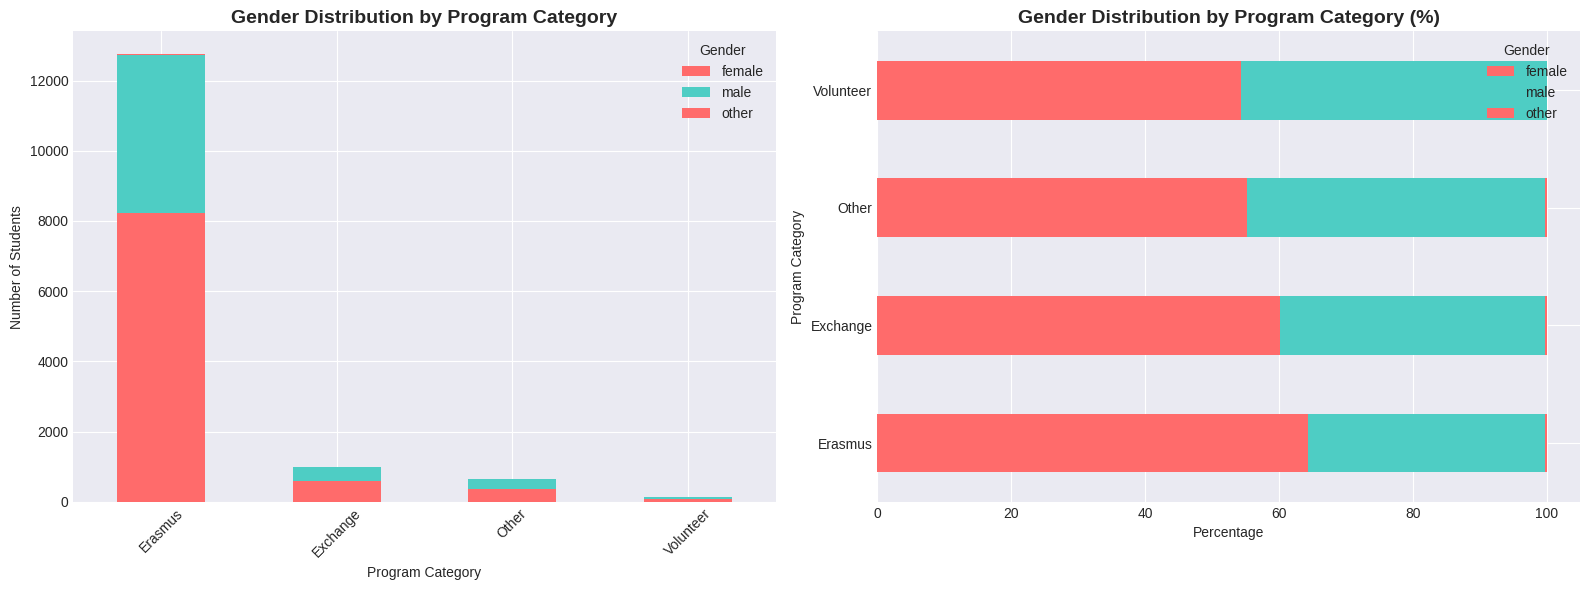

In [164]:
# Gender vs Program analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
gender_program = pd.crosstab(df['program_category'], df['gender'])
gender_program.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Gender Distribution by Program Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Program Category')
axes[0].set_ylabel('Number of Students')
axes[0].legend(title='Gender')
axes[0].tick_params(axis='x', rotation=45)

# Normalized percentages
gender_program_pct = pd.crosstab(df['program_category'], df['gender'], normalize='index') * 100
gender_program_pct.plot(kind='barh', stacked=True, ax=axes[1], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Gender Distribution by Program Category (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].set_ylabel('Program Category')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()


The female majority holds across all program types

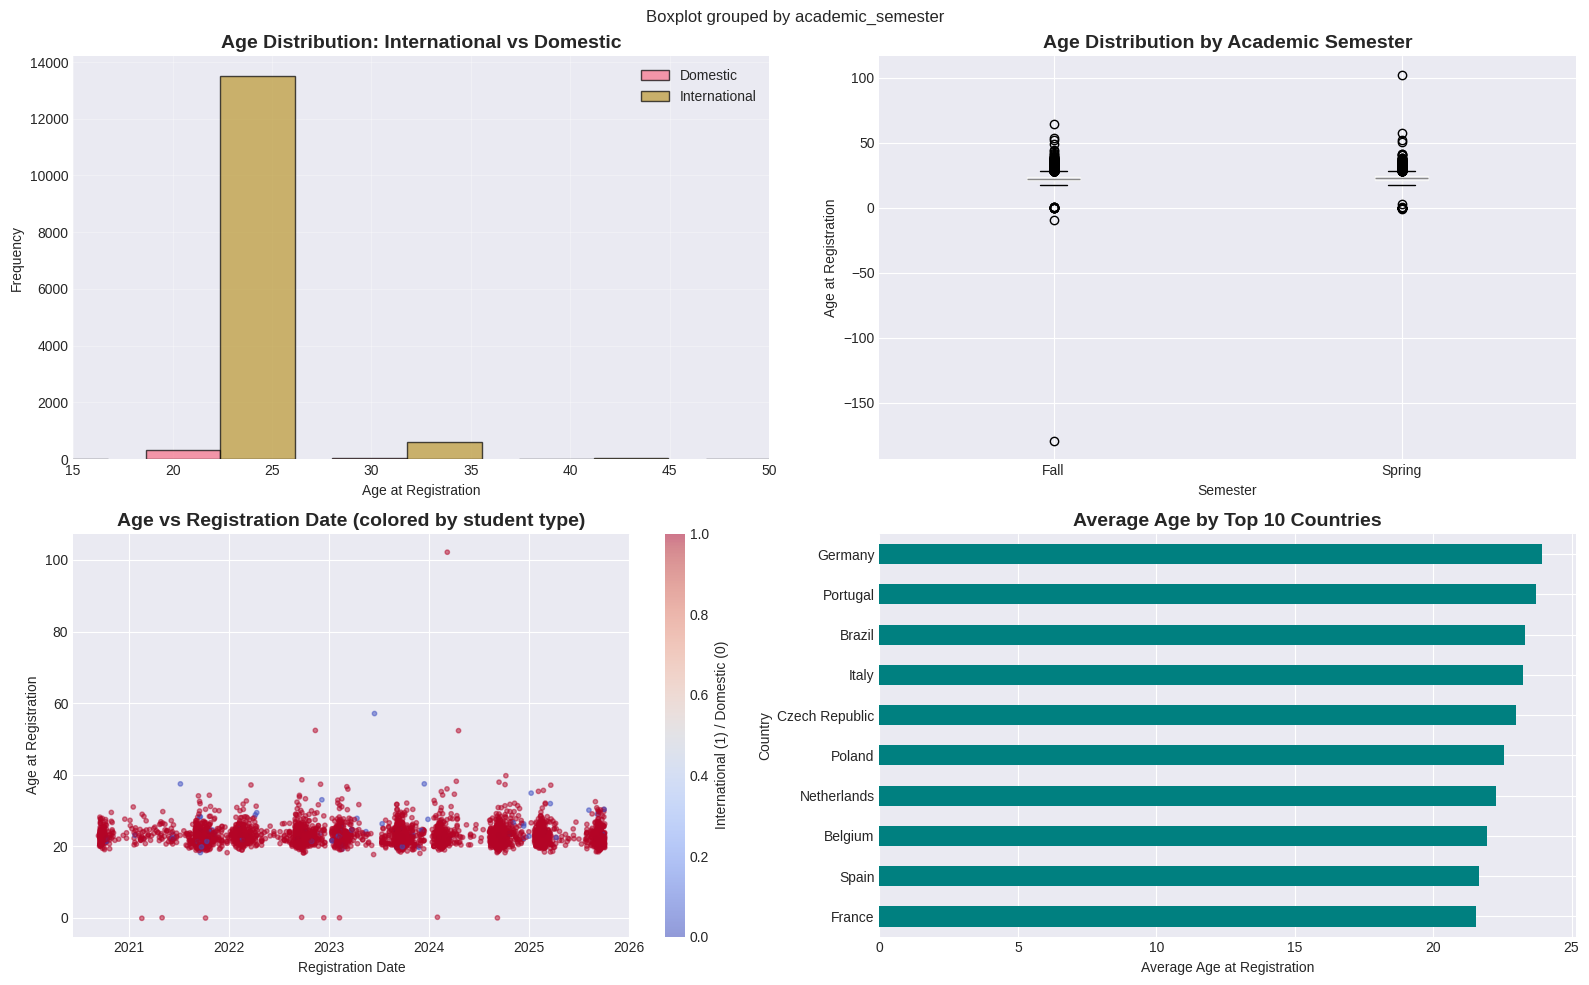


Age Statistics by Student Type:
                    count  mean  std     min   25%   50%   75%    max
is_international                                                     
0                  383.00 23.71 4.47   -0.59 21.36 22.76 24.88  57.07
1                14171.00 22.76 3.17 -179.35 21.18 22.44 23.88 102.17


In [165]:
# Age distribution by multiple factors
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age by international status
df_clean = df[df['age_at_registration'].notna()]
intl_age = df_clean[df_clean['is_international'] == 1]['age_at_registration']
domestic_age = df_clean[df_clean['is_international'] == 0]['age_at_registration']

axes[0, 0].hist([domestic_age, intl_age], bins=30, label=['Domestic', 'International'], 
                alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Age Distribution: International vs Domestic', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age at Registration')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(15, 50)

# Age by semester
df.boxplot(column='age_at_registration', by='academic_semester', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Academic Semester', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Semester')
axes[0, 1].set_ylabel('Age at Registration')

# Scatter: Age vs Registration Date
sample = df.sample(min(5000, len(df)))  # Sample for performance
scatter = axes[1, 0].scatter(sample['registerDate_dt'], sample['age_at_registration'], 
                             c=sample['is_international'], cmap='coolwarm', alpha=0.5, s=10)
axes[1, 0].set_title('Age vs Registration Date (colored by student type)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Registration Date')
axes[1, 0].set_ylabel('Age at Registration')
plt.colorbar(scatter, ax=axes[1, 0], label='International (1) / Domestic (0)')

# Average age by top countries
top_countries = df['country'].value_counts().head(10).index
age_by_country = df[df['country'].isin(top_countries)].groupby('country')['age_at_registration'].mean().sort_values()
age_by_country.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Average Age by Top 10 Countries', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Age at Registration')
axes[1, 1].set_ylabel('Country')

plt.tight_layout()
plt.show()

print("\nAge Statistics by Student Type:")
print(df.groupby('is_international')['age_at_registration'].describe())

International students are slightly younger than domestic ones (22.8 vs 23.7 years). This makes sense as domestic ESN members tend to be older, more experienced students who've already been through exchanges themselves. Age patterns by country show minimal variation, clustering tightly around the 22-23 year range regardless of origin.

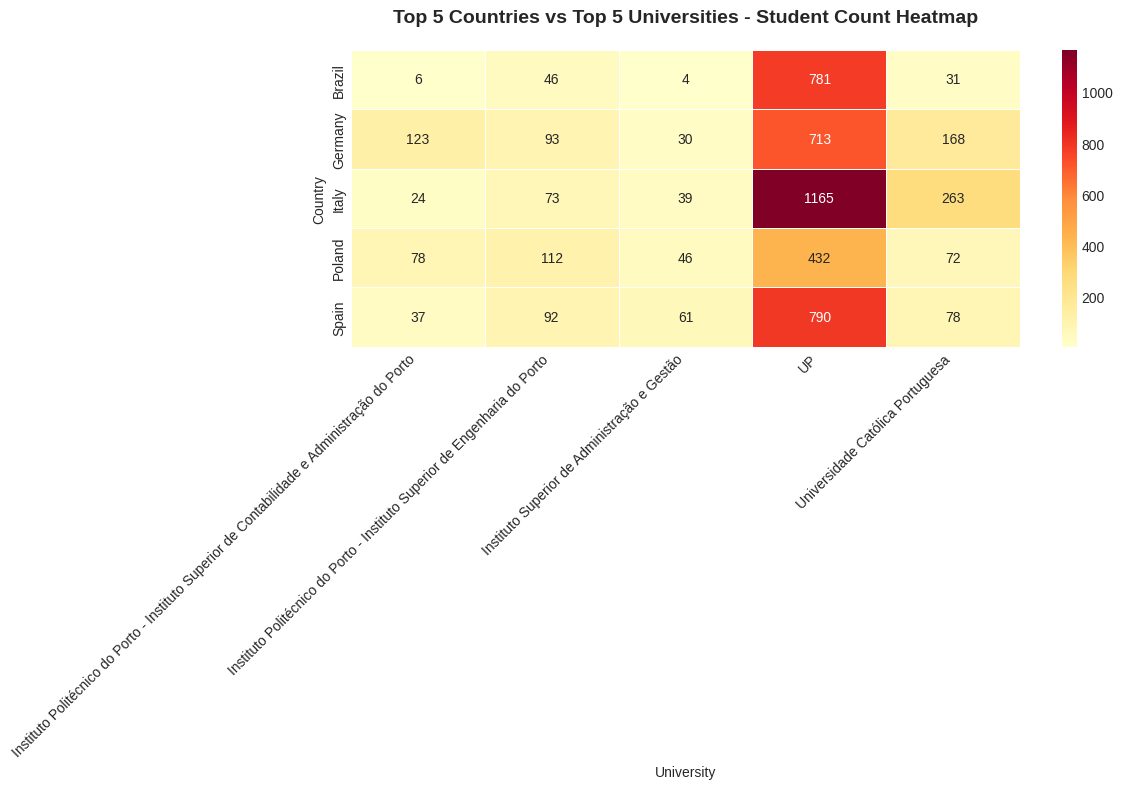

In [166]:
# Country vs University analysis
top_5_countries = df['country'].value_counts().head(5).index
top_5_unis = df['university_short'].value_counts().head(5).index

country_uni = pd.crosstab(
    df[df['country'].isin(top_5_countries)]['country'],
    df[df['university_short'].isin(top_5_unis)]['university_short']
)

plt.figure(figsize=(12, 8))
sns.heatmap(country_uni, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Top 5 Countries vs Top 5 Universities - Student Count Heatmap', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('University')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6.

### 6.1 Cohort Analysis

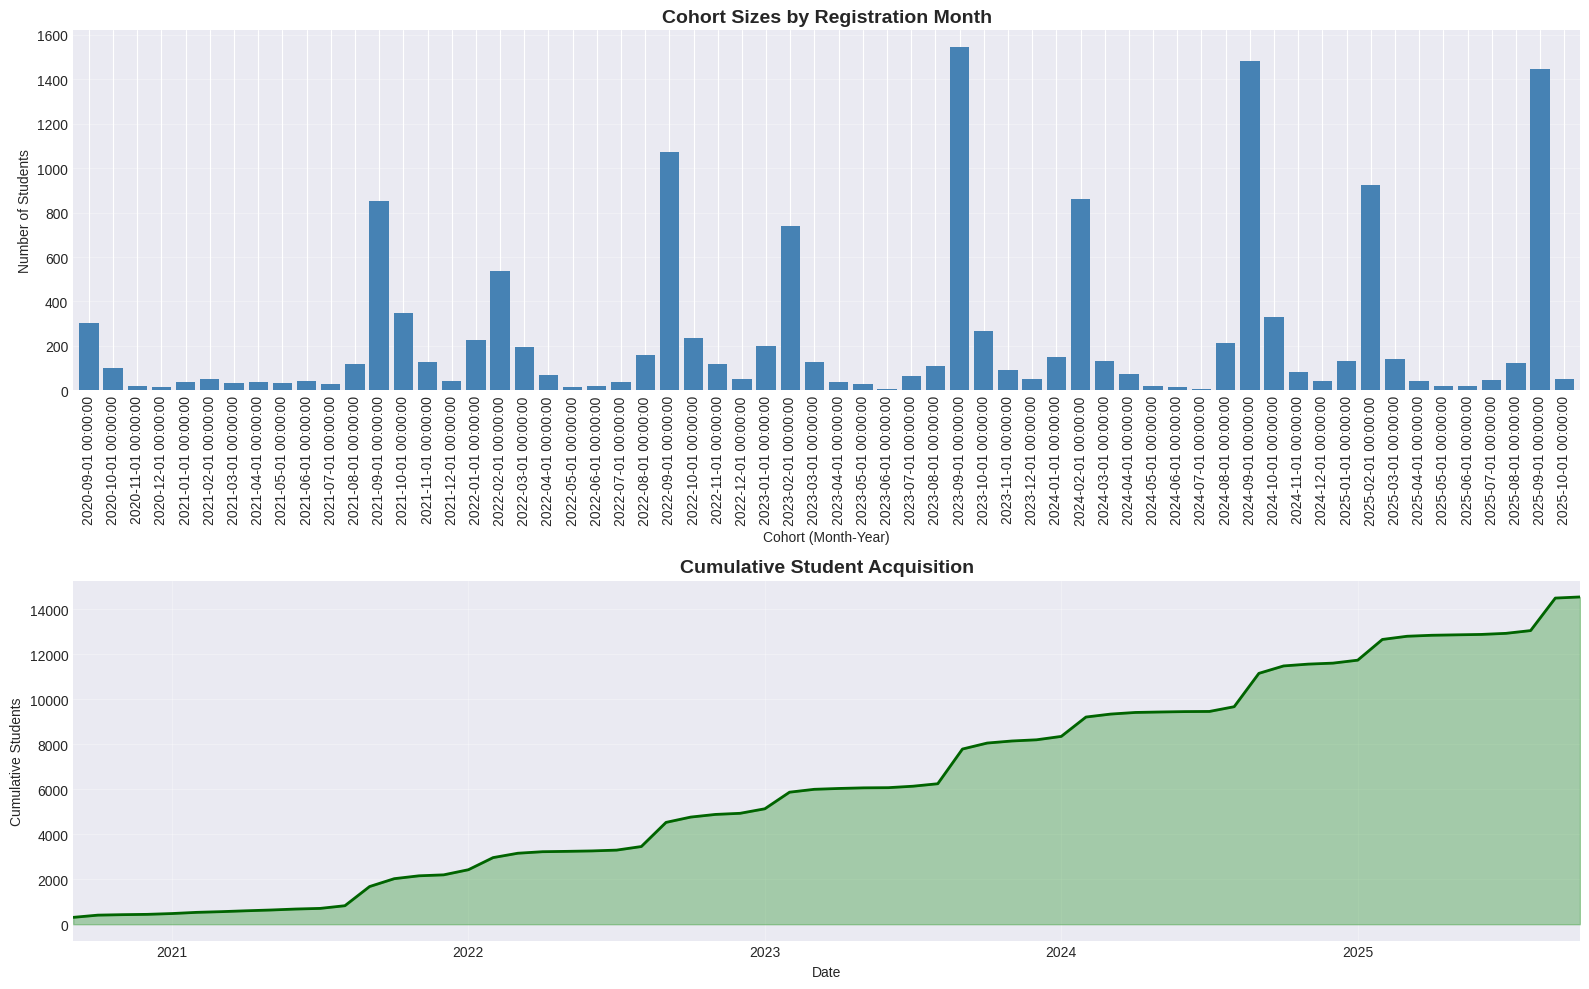

Total cohorts: 62
Average cohort size: 234.8
Largest cohort: 1543 (2023-09-01 00:00:00)
Smallest cohort: 7 (2024-07-01 00:00:00)


In [167]:
# Cohort analysis by registration month and year
df['cohort'] = df['registerDate_dt'].dt.to_period('M')

# Calculate cohort sizes
cohort_sizes = df.groupby('cohort').size()
cohort_sizes.index = cohort_sizes.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Cohort sizes over time
cohort_sizes.plot(kind='bar', ax=axes[0], color='steelblue', width=0.8)
axes[0].set_title('Cohort Sizes by Registration Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cohort (Month-Year)')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(alpha=0.3, axis='y')

# Cumulative student acquisition
cumulative = cohort_sizes.cumsum()
cumulative.plot(ax=axes[1], linewidth=2, color='darkgreen')
axes[1].fill_between(cumulative.index, 0, cumulative.values, alpha=0.3, color='green')
axes[1].set_title('Cumulative Student Acquisition', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Students')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total cohorts: {len(cohort_sizes)}")
print(f"Average cohort size: {cohort_sizes.mean():.1f}")
print(f"Largest cohort: {cohort_sizes.max()} ({cohort_sizes.idxmax()})")
print(f"Smallest cohort: {cohort_sizes.min()} ({cohort_sizes.idxmin()})")

Monthly cohort analysis shows massive spikes in September and smaller February peaks, aligning with academic semester starts. The cumulative curve shows steady growth through 2024 before the expected incomplete 2025-2026 data.

### 6.4 Time Series Analysis

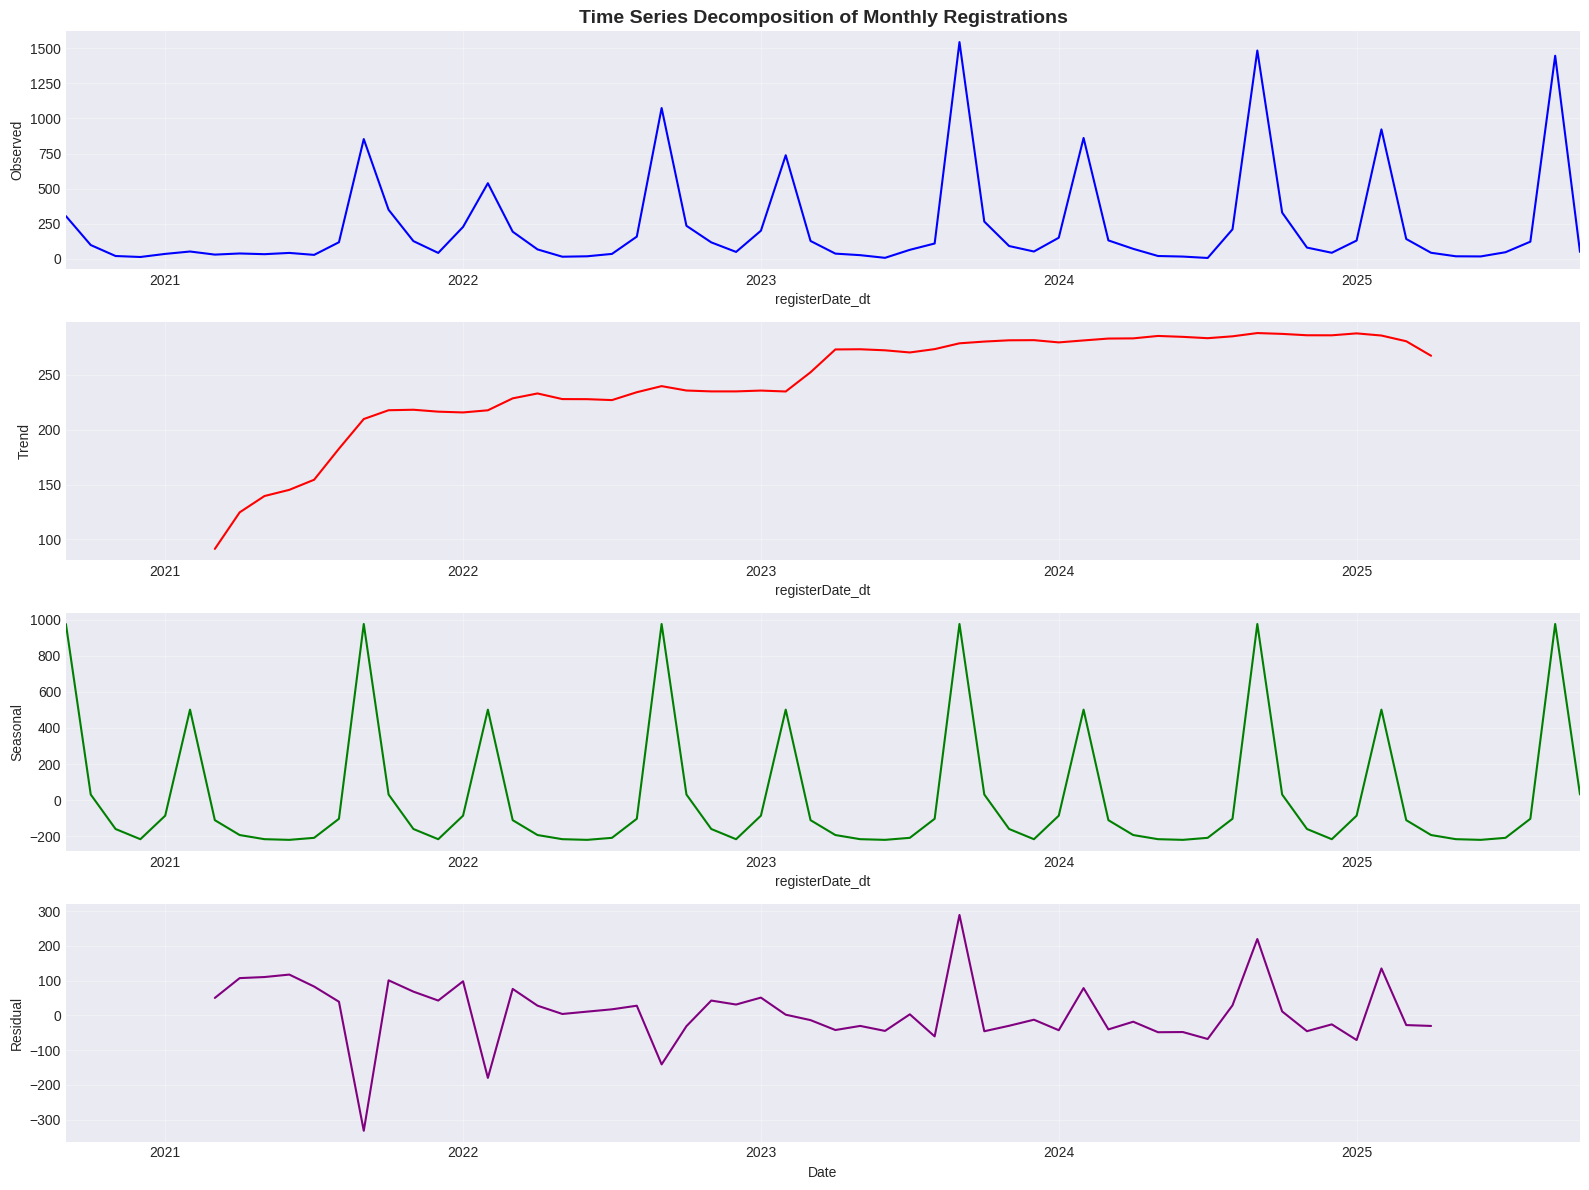

Time series decomposition completed successfully.


In [168]:
# Time series decomposition (if we have enough data)
monthly_reg = df.groupby(df['registerDate_dt'].dt.to_period('M')).size()
monthly_reg.index = monthly_reg.index.to_timestamp()

if len(monthly_reg) >= 24:  # Need at least 2 years of data
    # Resample to ensure regular frequency
    monthly_reg = monthly_reg.asfreq('MS', fill_value=0)
    
    # Decomposition
    decomposition = seasonal_decompose(monthly_reg, model='additive', period=12)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    decomposition.observed.plot(ax=axes[0], color='blue')
    axes[0].set_ylabel('Observed')
    axes[0].set_title('Time Series Decomposition of Monthly Registrations', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    decomposition.trend.plot(ax=axes[1], color='red')
    axes[1].set_ylabel('Trend')
    axes[1].grid(alpha=0.3)
    
    decomposition.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(alpha=0.3)
    
    decomposition.resid.plot(ax=axes[3], color='purple')
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Time series decomposition completed successfully.")
else:
    print(f"Not enough data for seasonal decomposition (need 24+ months, have {len(monthly_reg)})")

# Insert cell 36 conclusion here after moving

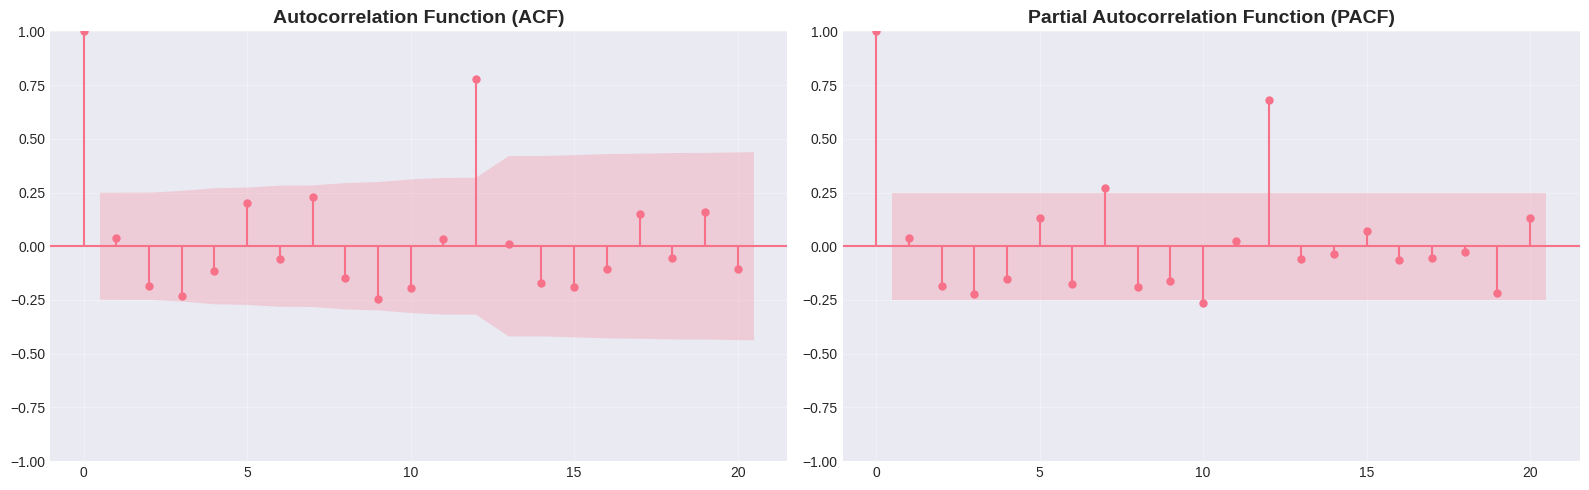

In [169]:
# ACF and PACF plots for time series analysis
if len(monthly_reg) >= 24:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    plot_acf(monthly_reg, lags=20, ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    plot_pacf(monthly_reg, lags=20, ax=axes[1])
    axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping ACF/PACF plots - insufficient data")

ACF shows strong autocorrelation at 12-month lags, confirming annual seasonality. The PACF cuts off sharply after lag 1, suggesting an AR(1) process with seasonal components. Together, these indicate a SARIMA model would be appropriate for forecasting - specifically, the patterns suggest seasonal differencing would be needed to achieve stationarity.

### 6.5 Geographic Analysis

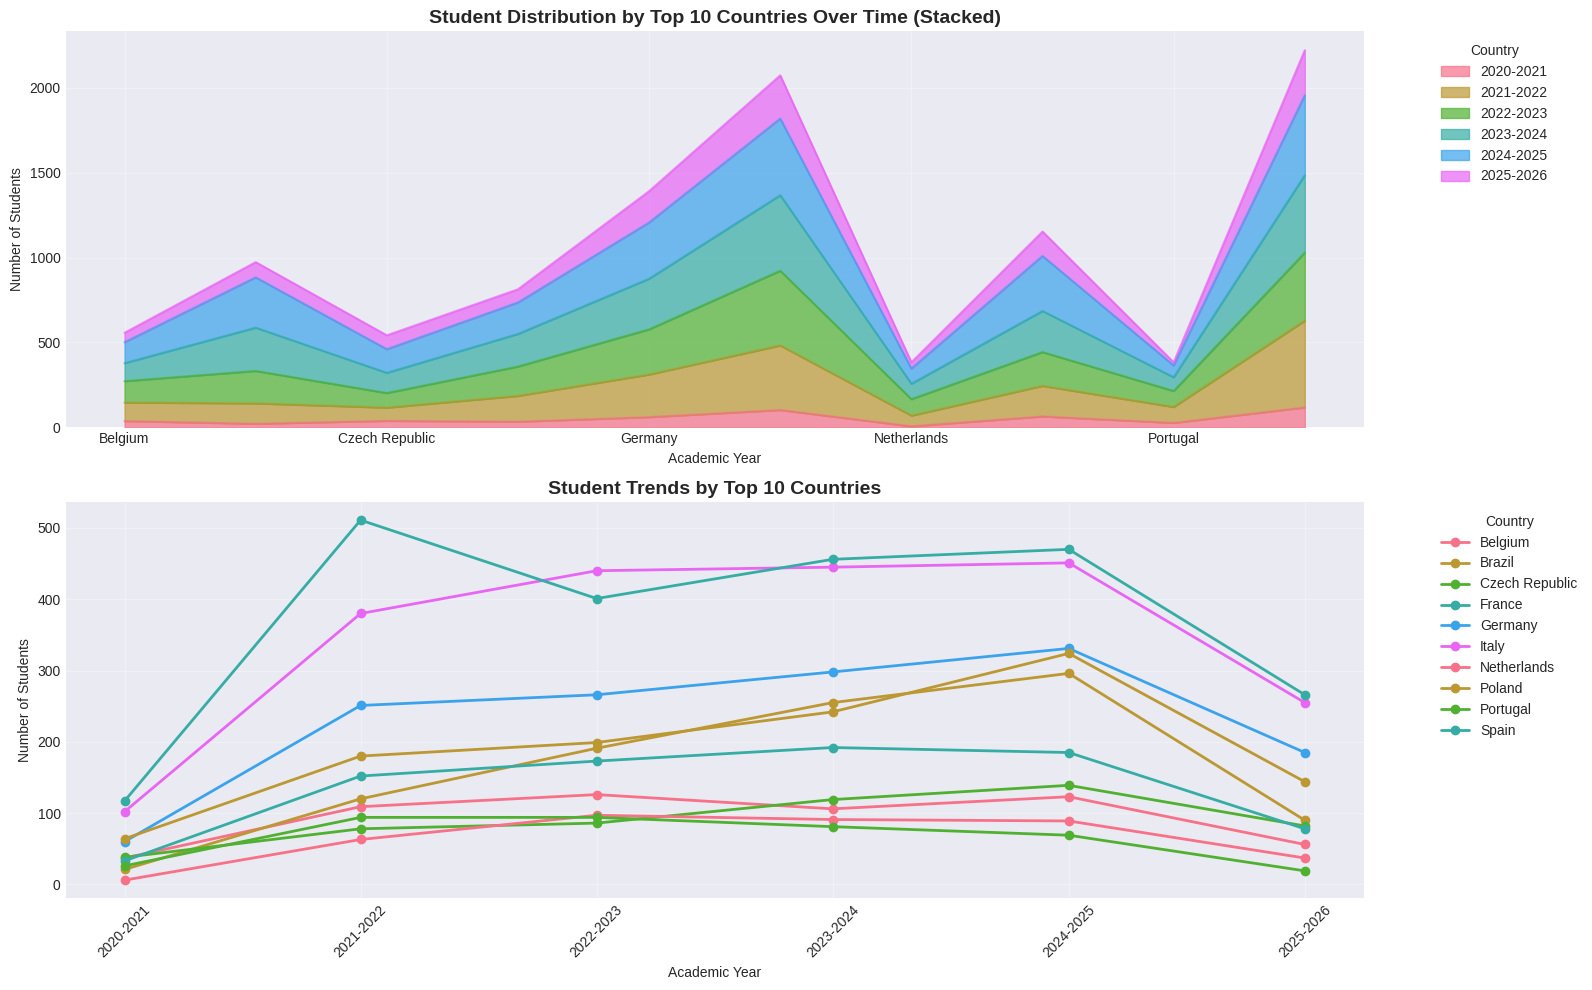

In [170]:
# Top countries analysis with temporal trends
top_10_countries = df['country'].value_counts().head(10).index

country_year = df[df['country'].isin(top_10_countries)].groupby(['academic_year', 'country']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Stacked area chart
country_year.T.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title('Student Distribution by Top 10 Countries Over Time (Stacked)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Academic Year')
axes[0].set_ylabel('Number of Students')
axes[0].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(alpha=0.3)

# Line chart for each country
country_year.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Student Trends by Top 10 Countries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
